In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/SCA_GE/Res2"

print(os.listdir(base_path))

['GE_curve_0.png', 'result_0.npy', 'training_log.csv', 'model_configuration_1.npy', 'GE_curve_1.npy', 'result_1.npy', 'model_configuration_0.npy', 'GE_curve_1.png', 'GE_curve_0.npy']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ge0 = np.load(os.path.join(base_path, "GE_curve_0 (1).npy"))
ge1 = np.load(os.path.join(base_path, "GE_curve_1 (1).npy"))

print("GE0 shape:", ge0.shape)
print("GE1 shape:", ge1.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/SCA_GE/Res2/GE_curve_0 (1).npy'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ge0 = np.load(os.path.join(base_path, "GE_curve_0.npy"))
ge1 = np.load(os.path.join(base_path, "GE_curve_1.npy"))

print("GE0 shape:", ge0.shape)
print("GE1 shape:", ge1.shape)

GE0 shape: (5000,)
GE1 shape: (5000,)


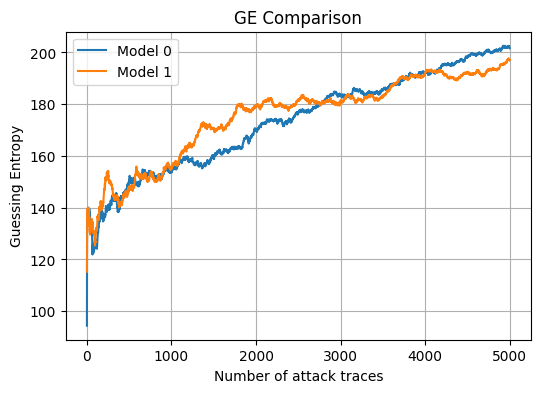

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(ge0, label="Model 0")
plt.plot(ge1, label="Model 1")

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("GE Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
res0 = np.load(os.path.join(base_path, "result_0.npy"), allow_pickle=True).item()
res1 = np.load(os.path.join(base_path, "result_1.npy"), allow_pickle=True).item()

print("Model 0:")
print("NTGE:", res0["NTGE"])
print("Final GE:", res0["GE"][-1])

print("\nModel 1:")
print("NTGE:", res1["NTGE"])
print("Final GE:", res1["GE"][-1])

Model 0:
NTGE: inf
Final GE: 201.6

Model 1:
NTGE: inf
Final GE: 197.1


In [ ]:
cfg0 = np.load(os.path.join(base_path, "model_configuration_0.npy"), allow_pickle=True).item()
cfg1 = np.load(os.path.join(base_path, "model_configuration_1.npy"), allow_pickle=True).item()

print("Config 0:", cfg0)
print("Config 1:", cfg1)

Config 0: {'batch_size': 128, 'lr': 0.003185689236450037, 'heads': 4, 'layers': 4}
Config 1: {'batch_size': 128, 'lr': 0.003252010186634677, 'heads': 8, 'layers': 4}


In [ ]:
print("GE0 min:", np.min(ge0), "max:", np.max(ge0))
print("GE1 min:", np.min(ge1), "max:", np.max(ge1))

print("Improving?")
print("Model 0:", ge0[-1] < ge0[0])
print("Model 1:", ge1[-1] < ge1[0])

GE0 min: 94.41 max: 202.59
GE1 min: 115.26 max: 197.64
Improving?
Model 0: False
Model 1: False


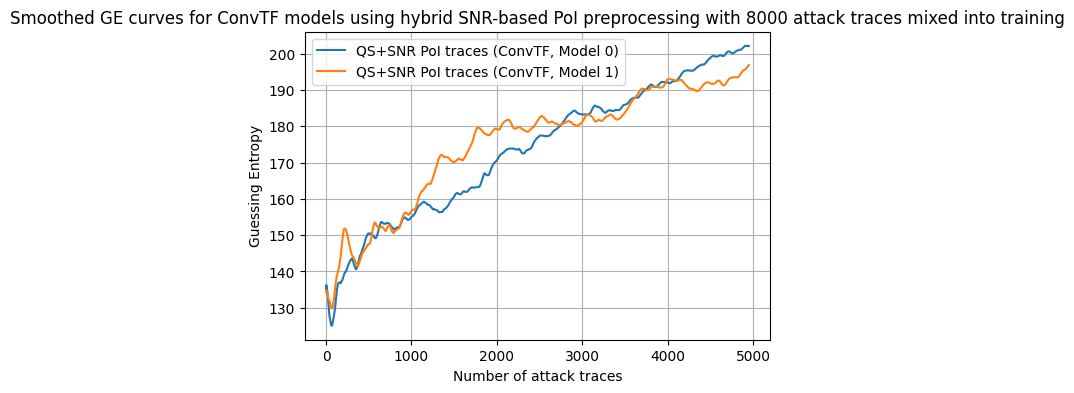

In [ ]:
def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(6,4))

plt.plot(smooth(ge0), label="QS+SNR PoI traces (ConvTF, Model 0)")
plt.plot(smooth(ge1), label="QS+SNR PoI traces (ConvTF, Model 1)")

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("Smoothed GE curves for ConvTF models using hybrid SNR-based PoI preprocessing with 8000 attack traces mixed into training")
plt.legend()
plt.grid()

plt.show()

In [ ]:

# ===== Imports =====
import os
import numpy as np
import matplotlib.pyplot as plt

# ===== Path to your folder =====
base_path ="/content/drive/MyDrive/Colab Notebooks/SCA_GE/Res0"

files = os.listdir(base_path)

# ===== Collect all GE curves =====
ge_files = sorted([f for f in files if "GE_curve" in f and f.endswith(".npy")])

print("Found GE files:")
for f in ge_files:
    print(f)

# ===== Load all curves =====
curves = {}
for f in ge_files:
    path = os.path.join(base_path, f)
    try:
        ge = np.load(path)
        curves[f] = ge
    except Exception as e:
        print(f"Error loading {f}: {e}")

print(f"\nLoaded {len(curves)} GE curves")

# ===== Plot all curves =====
plt.figure(figsize=(8,5))

for name, ge in curves.items():
    plt.plot(ge, label=name, alpha=0.8)

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("GE Curves (All Experiments)")
plt.legend(fontsize=8)
plt.grid()
plt.show()

# ===== Smooth version (better for paper) =====
def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(8,5))

for name, ge in curves.items():
    if len(ge) > 50:
        plt.plot(smooth(ge), label=name, alpha=0.8)

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("Smoothed GE Curves (All Experiments)")
plt.legend(fontsize=8)
plt.grid()
plt.show()

# ===== Print stats =====
print("\n===== SUMMARY =====")
for name, ge in curves.items():
    print(f"\n{name}")
    print(f"  min GE: {np.min(ge):.2f}")
    print(f"  max GE: {np.max(ge):.2f}")
    print(f"  improving? {ge[-1] < ge[0]}")

In [ ]:

# ===== Imports =====
import os
import numpy as np
import matplotlib.pyplot as plt

# ===== Path to your folder =====
base_path ="/content/drive/MyDrive/Colab Notebooks/SCA_GE/Res3"

files = os.listdir(base_path)

# ===== Collect all GE curves =====
ge_files = sorted([f for f in files if "GE_curve" in f and f.endswith(".npy")])

print("Found GE files:")
for f in ge_files:
    print(f)

# ===== Load all curves =====
curves = {}
for f in ge_files:
    path = os.path.join(base_path, f)
    try:
        ge = np.load(path)
        curves[f] = ge
    except Exception as e:
        print(f"Error loading {f}: {e}")

print(f"\nLoaded {len(curves)} GE curves")

# ===== Plot all curves =====
plt.figure(figsize=(8,5))

for name, ge in curves.items():
    plt.plot(ge, label=name, alpha=0.8)

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("GE Curves (All Experiments)")
plt.legend(fontsize=8)
plt.grid()
plt.show()

# ===== Smooth version (better for paper) =====
def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(8,5))

for name, ge in curves.items():
    if len(ge) > 50:
        plt.plot(smooth(ge), label=name, alpha=0.8)

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("Smoothed GE Curves (All Experiments)")
plt.legend(fontsize=8)
plt.grid()
plt.show()

# ===== Print stats =====
print("\n===== SUMMARY =====")
for name, ge in curves.items():
    print(f"\n{name}")
    print(f"  min GE: {np.min(ge):.2f}")
    print(f"  max GE: {np.max(ge):.2f}")
    print(f"  improving? {ge[-1] < ge[0]}")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Colab Notebooks/SCA_GE"

folders = ["Res0", "Res2", "Res3"]

ge0_all = []
ge1_all = []

# Load data
for folder in folders:
    path = os.path.join(base_path, folder)

    ge0 = np.load(os.path.join(path, "GE_curve_0.npy"))
    ge1 = np.load(os.path.join(path, "GE_curve_1.npy"))

    ge0_all.append(ge0)
    ge1_all.append(ge1)

# ---------------------------
# Plot GE0
# ---------------------------
plt.figure()

for i, ge0 in enumerate(ge0_all):
    plt.plot(ge0, label=f"{folders[i]} - GE0")

plt.xlabel("Trace Number")
plt.ylabel("Guessing Entropy")
plt.title("GE0 Comparison")
plt.legend()
plt.grid()

plt.show()

# ---------------------------
# Plot GE1
# ---------------------------
plt.figure()

for i, ge1 in enumerate(ge1_all):
    plt.plot(ge1, label=f"{folders[i]} - GE1")

plt.xlabel("Trace Number")
plt.ylabel("Guessing Entropy")
plt.title("GE1 Comparison")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Colab Notebooks/SCA_GE/Res0"

files = os.listdir(base_path)

# Separate files
ge0_files = sorted([f for f in files if "GE_curve_0" in f])
ge1_files = sorted([f for f in files if "GE_curve_1" in f])

print("GE0 files:", ge0_files)
print("GE1 files:", ge1_files)

# Load
ge0_curves = {}
ge1_curves = {}

for f in ge0_files:
    ge0_curves[f] = np.load(os.path.join(base_path, f))

for f in ge1_files:
    ge1_curves[f] = np.load(os.path.join(base_path, f))

# ===== Smooth function =====
def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

# ===========================
# 📊 Plot GE0 ONLY
# ===========================
plt.figure(figsize=(8,5))

for name, ge in ge0_curves.items():
    if len(ge) > 50:
        plt.plot(smooth(ge), label=name)

plt.title("Smoothed GE Curves - Model 0")
plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.legend(fontsize=8)
plt.grid()

plt.show()

# ===========================
# 📊 Plot GE1 ONLY
# ===========================
plt.figure(figsize=(8,5))

for name, ge in ge1_curves.items():
    if len(ge) > 50:
        plt.plot(smooth(ge), label=name)

plt.title("Smoothed GE Curves - Model 1")
plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.legend(fontsize=8)
plt.grid()

plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Colab Notebooks/SCA_GE"
folders = ["Res0", "Res2", "Res3"]

res0_all = []
res1_all = []

# ---------------------------
# Load data correctly
# ---------------------------
for folder in folders:
    path = os.path.join(base_path, folder)

    res0 = np.load(os.path.join(path, "result_0.npy"), allow_pickle=True).item()
    res1 = np.load(os.path.join(path, "result_1.npy"), allow_pickle=True).item()

    # ✅ extract GE
    res0 = res0['GE']
    res1 = res1['GE']

    res0_all.append(res0)
    res1_all.append(res1)

# ---------------------------
# Plot result_0
# ---------------------------
plt.figure()

for i, res0 in enumerate(res0_all):
    plt.plot(res0, label=f"{folders[i]} - result_0")

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("result_0 (GE) Comparison")
plt.legend()
plt.grid()

plt.show()

# ---------------------------
# Plot result_1
# ---------------------------
plt.figure()

for i, res1 in enumerate(res1_all):
    plt.plot(res1, label=f"{folders[i]} - result_1")

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("result_1 (GE) Comparison")
plt.legend()
plt.yscale('log')
plt.grid()

plt.show()

In [ ]:

print(type(res0))
print(res0)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Colab Notebooks/SCA_GE"

# Map folders to clear labels
folder_labels = {
    "Res0": "GO (seed = 0, raw traces)",
    "Res2": "G1 (seed = 2, with SNR)",
    "Res3": "G2 (seed = 3, without SNR)"
}

folders = list(folder_labels.keys())

ge0_all = []
ge1_all = []

# Load data
for folder in folders:
    path = os.path.join(base_path, folder)

    ge0 = np.load(os.path.join(path, "GE_curve_0.npy"))
    ge1 = np.load(os.path.join(path, "GE_curve_1.npy"))

    ge0_all.append(ge0)
    ge1_all.append(ge1)

# ---------------------------
# Plot GE0
# ---------------------------
plt.figure()

for i, ge0 in enumerate(ge0_all):
    plt.plot(ge0, label=folder_labels[folders[i]])

plt.xlabel("Trace Number")
plt.ylabel("Guessing Entropy")

plt.title(
    "GE0 Comparison of Models with Different Seeds and Preprocessing\n"
    "(Raw Traces vs SNR-Based Features)"
)

plt.legend()
plt.grid()

# Caption (for papers / reports)
plt.figtext(
    0.5, -0.1,
    "This plot compares the performance of models initialized with different seeds "
    "(GO: seed 0, G1: seed 2, G2: seed 3) when applied to raw traces and traces "
    "processed using SNR-based feature selection.",
    ha="center", fontsize=9
)

plt.show()

# ---------------------------
# Plot GE1
# ---------------------------
plt.figure()

for i, ge1 in enumerate(ge1_all):
    plt.plot(ge1, label=folder_labels[folders[i]])

plt.xlabel("Trace Number")
plt.ylabel("Guessing Entropy")

plt.title(
    "GE1 Comparison of Models with Different Seeds and Preprocessing\n"
    "(Raw Traces vs SNR-Based Features)"
)

plt.legend()
plt.grid()

plt.figtext(
    0.5, -0.1,
    "This plot compares the performance of models initialized with different seeds "
    "(GO: seed 0, G1: seed 2, G2: seed 3) under different preprocessing settings "
    "(raw traces vs SNR-based traces).",
    ha="center", fontsize=9
)

plt.show()

In [ ]:
def smooth_curve(curve, window=50):
    return np.convolve(curve, np.ones(window)/window, mode='valid')

In [ ]:
plt.figure()

for i, ge0 in enumerate(ge0_all):
    ge0_smooth = smooth_curve(ge0, window=50)
    plt.plot(ge0_smooth, label=folder_labels[folders[i]])

plt.xlabel("Trace Number")
plt.ylabel("Guessing Entropy")



plt.legend()
plt.grid()


plt.show()

In [ ]:
plt.figure()

for i, ge1 in enumerate(ge1_all):
    ge1_smooth = smooth_curve(ge1, window=50)
    plt.plot(ge1_smooth, label=folder_labels[folders[i]])

plt.xlabel("Trace Number")
plt.ylabel("Guessing Entropy")

plt.title(
    "Smoothed GE1 Comparison of Model with Seed0"
    "applied on Raw Traces vs SNR-Based Featurestraces and Qs+SNR traces"
)

plt.legend()
plt.grid()



plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Colab Notebooks/SCA_GE/"
folders = ["Res0", "Res2", "Res3"]


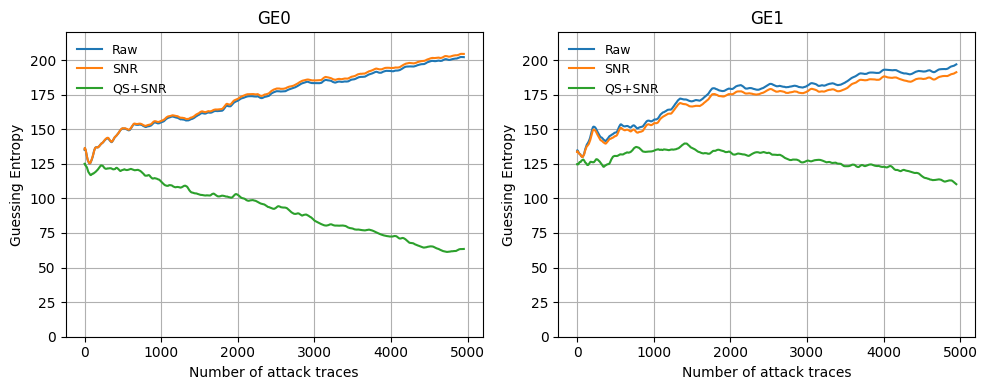

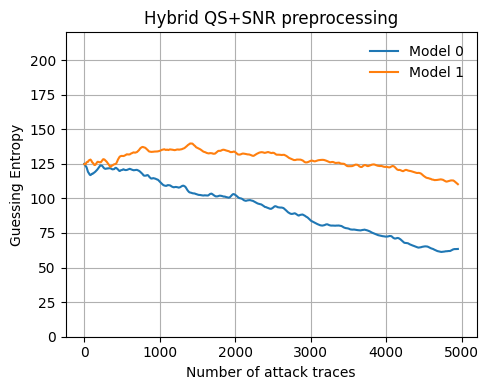

In [ ]:
# =========================
# CORRECT LABELS (FINAL)
# =========================
labels_map = {
    "Res0": "QS+SNR",   # BEST (decreasing GE)
    "Res2": "Raw",      # WORST
    "Res3": "SNR"       # middle
}

# Ensure consistent order in plots
folders = ["Res2", "Res3", "Res0"]  # Raw → SNR → QS+SNR

# =========================
# SMOOTHING
# =========================
def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

# =========================
# LOAD DATA
# =========================
ge0_all = []
ge1_all = []

for folder in folders:
    path = os.path.join(base_path, folder)
    ge0 = np.load(os.path.join(path, "GE_curve_0.npy"))
    ge1 = np.load(os.path.join(path, "GE_curve_1.npy"))
    ge0_all.append(ge0)
    ge1_all.append(ge1)

# =========================
# FIGURE 9 (MAIN PAPER FIGURE)
# =========================
plt.figure(figsize=(10,4))

# ---- LEFT: GE0 ----
plt.subplot(1,2,1)
for i, ge0 in enumerate(ge0_all):
    plt.plot(smooth(ge0), label=labels_map[folders[i]])

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("GE0")
plt.legend(fontsize=9, frameon=False)
plt.grid()
plt.ylim(0, 220)

# ---- RIGHT: GE1 ----
plt.subplot(1,2,2)
for i, ge1 in enumerate(ge1_all):
    plt.plot(smooth(ge1), label=labels_map[folders[i]])

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("GE1")
plt.legend(fontsize=9, frameon=False)
plt.grid()
plt.ylim(0, 220)

plt.tight_layout()
plt.savefig("Figure9_GE_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# =========================
# FIGURE 8 (HYBRID ONLY)
# =========================
# ✅ Correct: QS+SNR = Res0
path = os.path.join(base_path, "Res0")

ge0 = np.load(os.path.join(path, "GE_curve_0.npy"))
ge1 = np.load(os.path.join(path, "GE_curve_1.npy"))

plt.figure(figsize=(5,4))

plt.plot(smooth(ge0), label="Model 0")
plt.plot(smooth(ge1), label="Model 1")

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("Hybrid QS+SNR preprocessing")
plt.legend(fontsize=10, frameon=False)
plt.grid()
plt.ylim(0, 220)

plt.tight_layout()
plt.savefig("Figure8_Hybrid.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
for folder in ["Res0", "Res2", "Res3"]:
    path = os.path.join(base_path, folder)

    ge0 = np.load(os.path.join(path, "GE_curve_0.npy"))

    print(f"\n{folder}")
    print("Start:", ge0[0], "End:", ge0[-1])
    print("Improving?", ge0[-1] < ge0[0])


Res0
Start: 136.77 End: 64.0
Improving? True

Res2
Start: 94.41 End: 201.6
Improving? False

Res3
Start: 101.25 End: 203.95
Improving? False


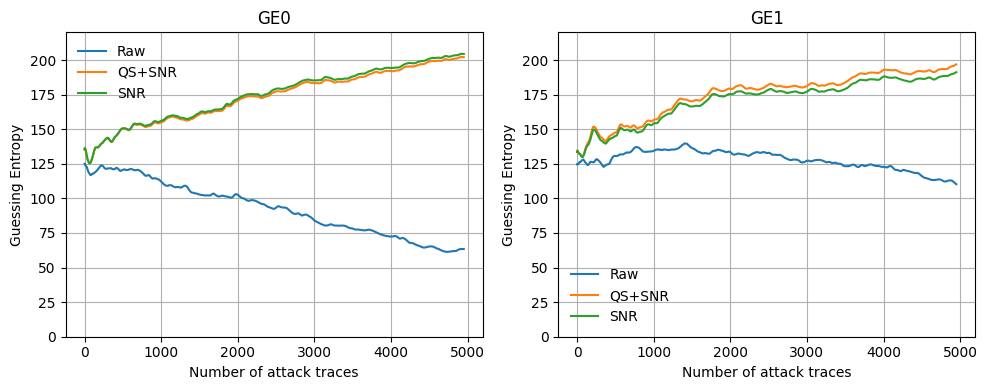

In [ ]:

folders = ["Res0", "Res2", "Res3"]

labels_map = {
    "Res0": "Raw",
    "Res2": "QS+SNR",
    "Res3": "SNR"
}

def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

def load_all_curves(folder_path, prefix):
    files = os.listdir(folder_path)
    curves = []

    for f in files:
        if prefix in f and f.endswith(".npy"):
            curves.append(np.load(os.path.join(folder_path, f)))

    return curves

def average_curves(curves):
    min_len = min(len(c) for c in curves)
    curves = [c[:min_len] for c in curves]
    return np.mean(curves, axis=0)

# =========================
# LOAD + AVERAGE
# =========================
ge0_all = []
ge1_all = []

for folder in folders:
    path = os.path.join(base_path, folder)

    ge0_curves = load_all_curves(path, "GE_curve_0")
    ge1_curves = load_all_curves(path, "GE_curve_1")

    ge0_avg = average_curves(ge0_curves)
    ge1_avg = average_curves(ge1_curves)

    ge0_all.append(ge0_avg)
    ge1_all.append(ge1_avg)

# =========================
# FIGURE 9 (FINAL CLEAN)
# =========================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
for i, ge0 in enumerate(ge0_all):
    plt.plot(smooth(ge0), label=labels_map[folders[i]])
plt.title("GE0")
plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.legend(frameon=False)
plt.grid()
plt.ylim(0, 220)

plt.subplot(1,2,2)
for i, ge1 in enumerate(ge1_all):
    plt.plot(smooth(ge1), label=labels_map[folders[i]])
plt.title("GE1")
plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.legend(frameon=False)
plt.grid()
plt.ylim(0, 220)

plt.tight_layout()
plt.show()

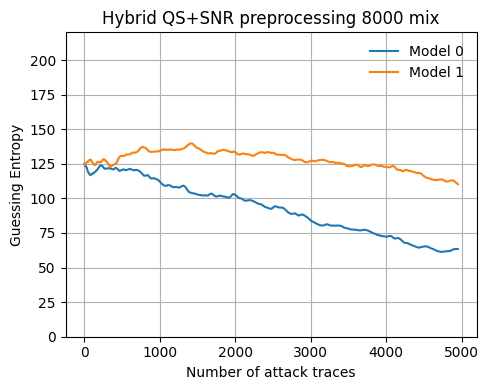

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Colab Notebooks/SCA_GE/"
folders = ["Res0", "Res2", "Res3"]


ge0 = np.load(os.path.join(path, "GE_curve_0.npy"))
ge1 = np.load(os.path.join(path, "GE_curve_1.npy"))

plt.figure(figsize=(5,4))

plt.plot(smooth(ge0), label="Model 0")
plt.plot(smooth(ge1), label="Model 1")

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.title("Hybrid QS+SNR preprocessing 8000 mix")
plt.legend(fontsize=10, frameon=False)
plt.grid()
plt.ylim(0, 220)

plt.tight_layout()
plt.savefig("Figure8_Hybrid.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
labels_map = {
    "Res0": "QS+SNR",
    "Res2": "Raw",
    "Res3": "SNR"
}

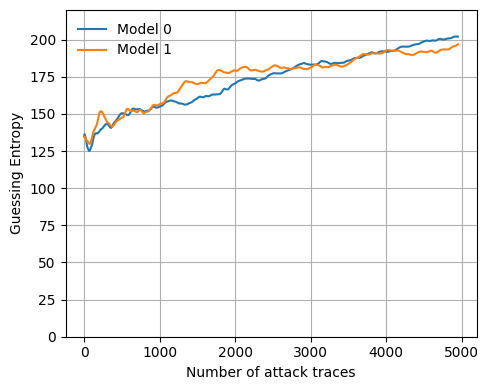

In [ ]:
# =========================
# RAW ONLY (Res2)
# =========================
path = os.path.join(base_path, "Res2")

ge0_curves = load_all_curves(path, "GE_curve_0")
ge1_curves = load_all_curves(path, "GE_curve_1")

ge0_avg = average_curves(ge0_curves)
ge1_avg = average_curves(ge1_curves)

plt.figure(figsize=(5,4))

plt.plot(smooth(ge0_avg), label="Model 0")
plt.plot(smooth(ge1_avg), label="Model 1")

plt.xlabel("Number of attack traces")
plt.ylabel("Guessing Entropy")
plt.legend(frameon=False)
plt.grid()
plt.ylim(0, 220)

plt.tight_layout()
plt.show()